In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_excel("Vrinda Store Data Analysis.xlsx")

df.head()

,index,Order ID,Cust ID,Gender,Age,Date,Status,Channel,SKU,Category,Size,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B
0,1,171-1029312-3038738,1029312,Women,44,2022-12-04,Delivered,Myntra,JNE1233-BLUE-KR-031-XXL,kurta,XXL,1,INR,376,MOHALI,PUNJAB,140301,IN,False
1,2,405-2183842-2225946,2183842,Women,29,2022-12-04,Delivered,Ajio,SET414-KR-NP-L,Set,L,1,INR,1449,GURUGRAM,HARYANA,122002,IN,False
2,3,171-1641533-8921966,1641533,Women,67,2022-12-04,Delivered,Myntra,SET261-KR-PP-S,Set,S,1,INR,453,KOLKATA,WEST BENGAL,700029,IN,False
3,4,404-7490807-6300351,7490807,Women,20,2022-12-04,Delivered,Amazon,SET110-KR-PP-M,Set,M,1,INR,729,THANJAVUR,TAMIL NADU,613007,IN,False
4,5,403-9293516-4577154,9293516,Women,62,2022-12-04,Delivered,Myntra,JNE2294-KR-A-XXL,kurta,XXL,1,INR,544,GURUGRAM,HARYANA,122001,IN,False


In [ ]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31047 entries, 0 to 31046
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   index             31047 non-null  int64         
 1   Order ID          31047 non-null  object        
 2   Cust ID           31047 non-null  int64         
 3   Gender            31047 non-null  object        
 4   Age               31047 non-null  int64         
 5   Date              31047 non-null  datetime64[ns]
 6   Status            31047 non-null  object        
 7   Channel           31047 non-null  object        
 8   SKU               31047 non-null  object        
 9   Category          31047 non-null  object        
 10  Size              31047 non-null  object        
 11  Qty               31047 non-null  object        
 12  currency          31047 non-null  object        
 13  Amount            31047 non-null  int64         
 14  ship-city         3104

,0
index,0
Order ID,0
Cust ID,0
Gender,0
Age,0
Date,0
Status,0
Channel,0
SKU,0
Category,0


In [ ]:
df['Gender'] = df['Gender'].replace({
    'M':'Men',
    'W':'Women'
})

df['Amount'] = pd.to_numeric(df['Amount'])

df.dropna(inplace=True)

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.month_name()

monthly_sales = df.groupby('Month')['Amount'].sum().sort_values(ascending=False)

monthly_sales

,Amount
Month,
March,1928066
February,1875932
April,1829263
January,1820601
August,1808505
May,1797822
July,1772300
June,1750966
September,1688871


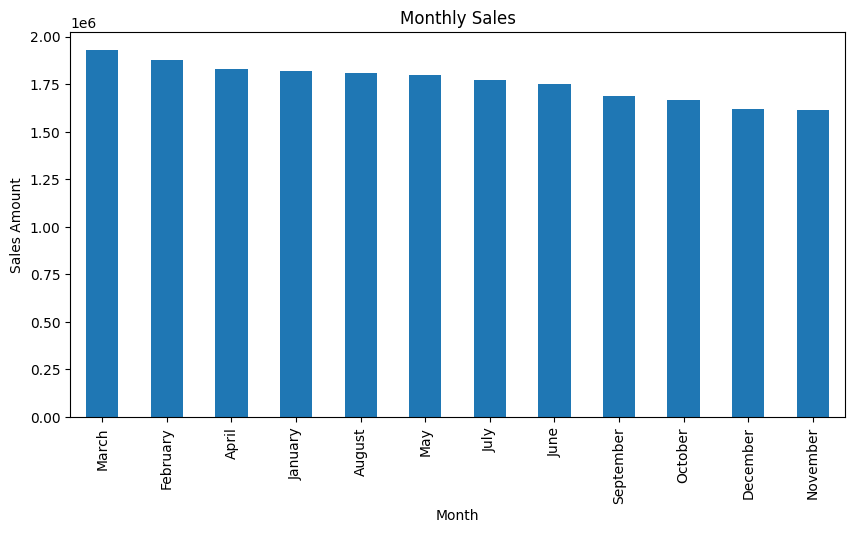

In [ ]:
plt.figure(figsize=(10,5))
monthly_sales.plot(kind='bar')
plt.title("Monthly Sales")
plt.ylabel("Sales Amount")
plt.show()

In [ ]:
gender_sales = df.groupby('Gender')['Amount'].sum()

gender_sales

,Amount
Gender,
Men,7613604
Women,13562773


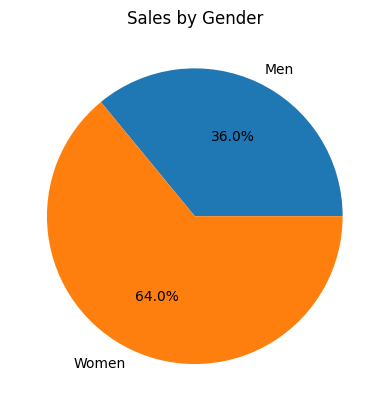

In [ ]:
gender_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales by Gender")
plt.ylabel("")
plt.show()

In [ ]:
top_states = df.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(10)

top_states

,Amount
ship-state,
MAHARASHTRA,2990221
KARNATAKA,2646358
UTTAR PRADESH,2104659
TELANGANA,1712439
TAMIL NADU,1678877
DELHI,1248111
KERALA,1008940
WEST BENGAL,922444
ANDHRA PRADESH,918499


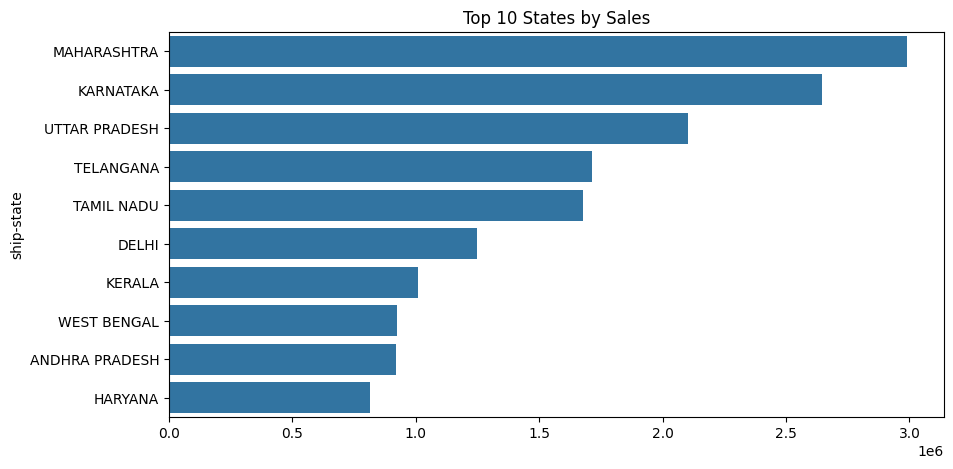

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x=top_states.values,y=top_states.index)
plt.title("Top 10 States by Sales")
plt.show()

In [ ]:
channel_sales = df.groupby('Channel ')['Amount'].sum().sort_values(ascending=False)

channel_sales

,Amount
Channel,
Amazon,7519933
Myntra,4941540
Flipkart,4573301
Ajio,1331427
Nalli,1015329
Meesho,927606
Others,867241


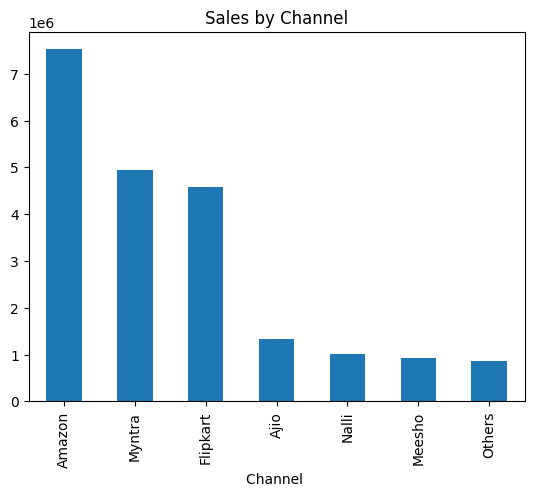

In [ ]:
channel_sales.plot(kind='bar')
plt.title("Sales by Channel")
plt.show()

In [ ]:
category_sales = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)

category_sales

,Amount
Category,
Set,10507546
kurta,4959377
Western Dress,3148836
Top,1186199
Saree,1010471
Ethnic Dress,195256
Blouse,140888
Bottom,27804


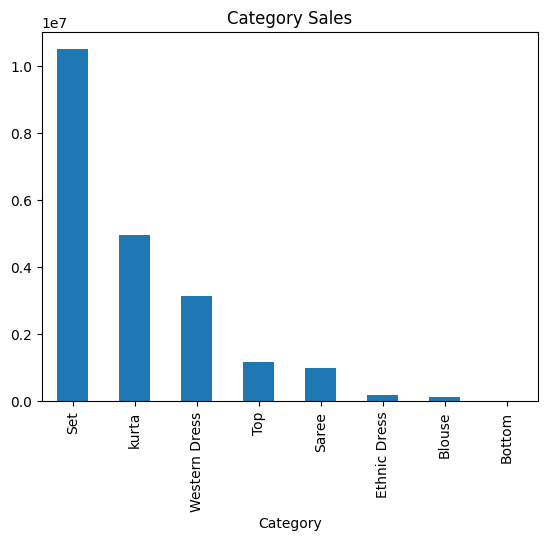

In [ ]:
category_sales.plot(kind='bar')
plt.title("Category Sales")
plt.show()

In [ ]:
bins = [0,20,30,40,50,100]
labels = ['0-20','21-30','31-40','41-50','50+']

df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

age_sales = df.groupby('Age Group')['Amount'].sum()

age_sales

/tmp/ipykernel_6735/2044188981.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_sales = df.groupby('Age Group')['Amount'].sum()


,Amount
Age Group,
0-20,1512064
21-30,5419608
31-40,5297831
41-50,4920222
50+,4026652


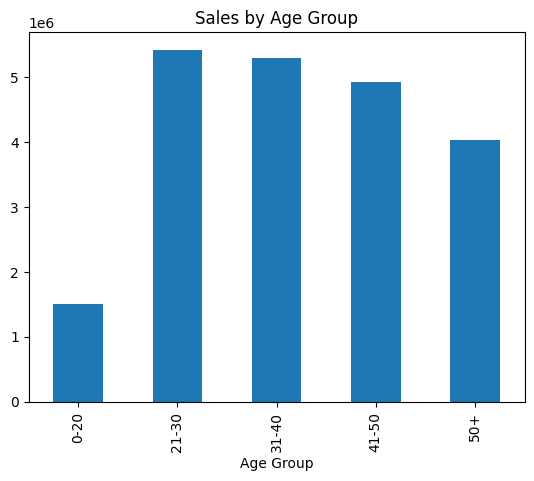

In [ ]:
age_sales.plot(kind='bar')
plt.title("Sales by Age Group")
plt.show()

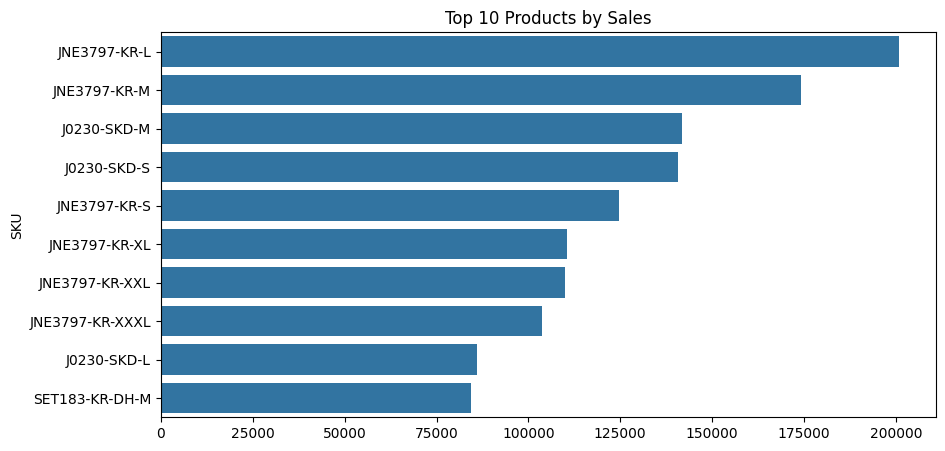

In [ ]:
# Top 10 Products
top_products = df.groupby('SKU')['Amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 10 Products by Sales")
plt.show()